# Red Generativa Antagónica (GAN) sobre Fashion MNIST

Lucho Ene | 2024 <br>
Hooked on a Feeling by Blue Swede

Este proyecto demuestra la implementación de una GAN (Red Generativa Antagónica) para generar artículos de moda utilizando el conjunto de datos Fashion MNIST, construido con PyTorch.

🔍 **Resumen**

- El Generador aprende a producir imágenes de moda realistas.
- El Discriminador aprende a diferenciar entre imágenes reales y falsas (generadas).
- Ambas redes mejoran iterativamente mediante un entrenamiento adversarial.

🛠️ **Tech Stack**

- Python
- PyTorch
- Torchvision
- Numpy
- Matplotlib

## Import Packages

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import sys

import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset

import matplotlib.pyplot as plt

### Import dataset

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [3]:
#Data Transformations and Loading
transform = T.Compose([
    T.ToTensor(),
    T.Resize(64), #GANS expects input size of 64*64
    T.Normalize(0.5,0.5),
])

dataset = torchvision.datasets.FashionMNIST(root='./data',download=True,transform=transform)

In [4]:
print(dataset.classes)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [5]:
#classes_to_focus = ['Trouser','Sneaker','Pullover']
classes_to_focus = ['Ankle boot','Coat','Bag']


images2focus = torch.Tensor()
for i in range(len(classes_to_focus)):
  classidx = dataset.classes.index(classes_to_focus[i])
  images2focus = torch.cat((images2focus,torch.where(dataset.targets==classidx)[0]),0).type(torch.long)
  print(f'Added class {classes_to_focus[i]} (index {classidx})')
     


Added class Ankle boot (index 9)
Added class Coat (index 4)
Added class Bag (index 8)


In [6]:
images2focus

tensor([    0,    11,    15,  ..., 59962, 59967, 59994])

In [7]:
batchsize = 100
sampler = torch.utils.data.sampler.SubsetRandomSampler(images2focus)
data_loader = DataLoader(dataset,sampler=sampler,batch_size = batchsize,drop_last=True)

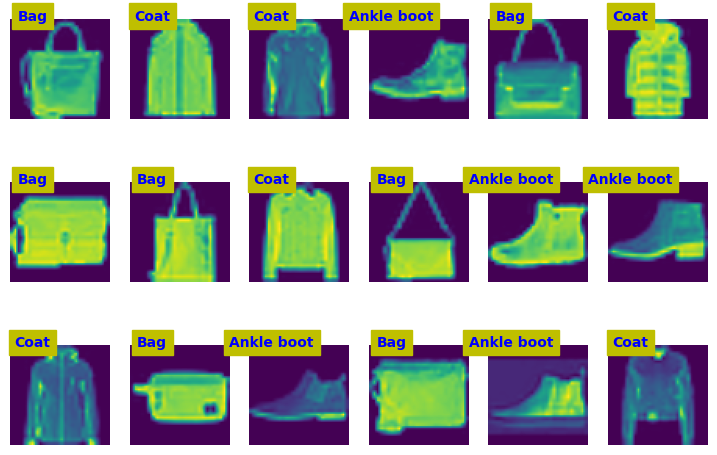

In [8]:
#Mirar algunas imagenes
X,y = next(iter(data_loader))

fig, axs = plt.subplots(3,6,figsize=(9,6))

for i, ax in enumerate(axs.flatten()):

  pic = torch.squeeze(X.data[i])
  pic = pic/2 + 0.5


  label = dataset.classes[y[i]]
  ax.imshow(pic)
  ax.text(14,0,label,ha='center',fontweight='bold',color ='blue', backgroundcolor='y')
  ax.axis('off')



plt.show()

### Creacion del discriminador de clases

In [9]:
class discriminatorNet(nn.Module):
  def __init__(self):
    super().__init__()


    #convolutional layers
    self.conv1 = nn.Conv2d(1,64,4,2,1,bias=False)
    self.conv2 = nn.Conv2d(64,128,4,2,1,bias=False)
    self.conv3 = nn.Conv2d(128,256,4,2,1,bias=False)
    self.conv4 = nn.Conv2d(256,512,4,2,1,bias=False)
    self.conv5 = nn.Conv2d(512,1,4,1,0,bias=False)

    #batch norm
    self.bn2 = nn.BatchNorm2d(128)
    self.bn3 = nn.BatchNorm2d(256)
    self.bn4 = nn.BatchNorm2d(512)

  def forward(self,x):
    x = F.leaky_relu(self.conv1(x), 0.2)
    x = F.leaky_relu_(self.conv2(x),0.2)
    x = self.bn2(x)
    x = F.leaky_relu(self.conv3(x),0.2)
    x = self.bn3(x)
    x = F.leaky_relu(self.conv4(x),0.2)
    x = self.bn4(x)
    return torch.sigmoid(self.conv5(x)).view(-1,1)
     


In [10]:
class discriminatorNet(nn.Module):
  def __init__(self):
    super().__init__()


    #convolutional layers
    self.conv1 = nn.Conv2d(1,64,4,2,1,bias=False)
    self.conv2 = nn.Conv2d(64,128,4,2,1,bias=False)
    self.conv3 = nn.Conv2d(128,256,4,2,1,bias=False)
    self.conv4 = nn.Conv2d(256,512,4,2,1,bias=False)
    self.conv5 = nn.Conv2d(512,1,4,1,0,bias=False)

    #batch norm
    self.bn2 = nn.BatchNorm2d(128)
    self.bn3 = nn.BatchNorm2d(256)
    self.bn4 = nn.BatchNorm2d(512)

  def forward(self,x):
    x = F.leaky_relu(self.conv1(x), 0.2)
    x = F.leaky_relu_(self.conv2(x),0.2)
    x = self.bn2(x)
    x = F.leaky_relu(self.conv3(x),0.2)
    x = self.bn3(x)
    x = F.leaky_relu(self.conv4(x),0.2)
    x = self.bn4(x)
    return torch.sigmoid(self.conv5(x)).view(-1,1)
     


In [11]:
class generatorNet(nn.Module):
  def __init__(self):
    super().__init__()
    #convolutional layers
    self.conv1 = nn.ConvTranspose2d(100,512,4,1,0,bias=False)
    self.conv2 = nn.ConvTranspose2d(512,256,4,2,1,bias=False)
    self.conv3 = nn.ConvTranspose2d(256,128,4,2,1,bias=False)
    self.conv4 = nn.ConvTranspose2d(128,64,4,2,1,bias=False)
    self.conv5 = nn.ConvTranspose2d(64,1,4,2,1,bias=False)


    #batch norm
    self.bn1 = nn.BatchNorm2d(512)
    self.bn2 = nn.BatchNorm2d(256)
    self.bn3 = nn.BatchNorm2d(128)
    self.bn4 = nn.BatchNorm2d(64)

  def forward(self,x):
    x = F.relu(self.bn1(self.conv1(x)))
    x = F.relu(self.bn2(self.conv2(x)))
    x = F.relu(self.bn3(self.conv3(x)))
    x = F.relu(self.bn4(self.conv4(x)))
    x = torch.tanh(self.conv5(x))
    return x
     


In [12]:
gnet = generatorNet()

torch.Size([10, 1, 64, 64])


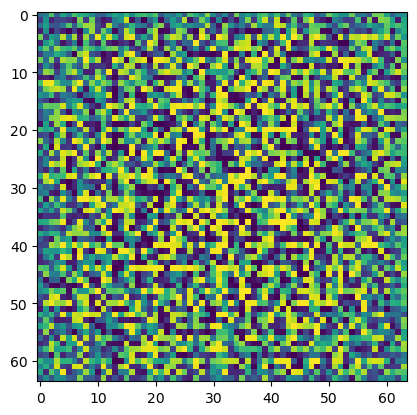

In [13]:
y = gnet(torch.randn(10,100,1,1))
print(y.shape)
plt.imshow(y[0,:,:,:].squeeze().detach().numpy())
plt.show()

In [14]:
lossfun = nn.BCELoss()

dnet = discriminatorNet().to(device)
gnet = generatorNet().to(device)

d_optimizer = torch.optim.Adam(dnet.parameters(),lr=0.0002,betas=(0.5,0.999))
g_optimizer = torch.optim.Adam(gnet.parameters(),lr=0.0002,betas=(0.5,0.999))

In [15]:
num_epochs = int(2500/len(data_loader))

In [16]:
losses = []
disDecs = []
metricas = []

# Crear etiquetas reales y falsas solo una vez (si el batchsize no cambia)
real_labels = torch.ones(batchsize, 1, device=device)
fake_labels = torch.zeros(batchsize, 1, device=device)

for ep in range(num_epochs):
    running_d_loss = 0.0
    running_g_loss = 0.0
    running_acc_real = 0.0
    running_acc_fake = 0.0
    count = 0

    for data, _ in data_loader:
        data = data.to(device, non_blocking=True)

        ## --- Entrenamiento del discriminador ---
        pred_real = dnet(data)
        d_loss_real = lossfun(pred_real, real_labels)

        z = torch.randn(batchsize, 100, 1, 1, device=device)
        fake_images = gnet(z).detach()
        pred_fake = dnet(fake_images)
        d_loss_fake = lossfun(pred_fake, fake_labels)

        d_loss = d_loss_real + d_loss_fake

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        ## --- Entrenamiento del generador ---
        z = torch.randn(batchsize, 100, 1, 1, device=device)
        fake_images = gnet(z)
        pred_fake = dnet(fake_images)

        g_loss = lossfun(pred_fake, real_labels)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        # Guardar las pérdidas
        losses.append([d_loss.item(), g_loss.item()])
        running_d_loss += d_loss.item()
        running_g_loss += g_loss.item()

        # Calcular precisiones
        acc_real = (pred_real > 0.5).float().mean().item()
        acc_fake = (pred_fake < 0.5).float().mean().item()
        acc_total = (acc_real + acc_fake) / 2.0

        running_acc_real += acc_real
        running_acc_fake += acc_fake

        disDecs.append([acc_real, 1.0 - acc_fake])
        count += 1

    # Calcular promedios de la época
    epoch_d_loss = running_d_loss / count
    epoch_g_loss = running_g_loss / count
    epoch_acc_real = running_acc_real / count
    epoch_acc_fake = running_acc_fake / count
    epoch_acc_total = (epoch_acc_real + epoch_acc_fake) / 2.0

    metricas.append([epoch_d_loss, epoch_g_loss, epoch_acc_real, epoch_acc_fake, epoch_acc_total])

    # Mostrar progreso con métricas
    print(f'Época {ep+1}/{num_epochs} | D_Loss: {epoch_d_loss:.4f} | G_Loss: {epoch_g_loss:.4f} | Acc_R: {epoch_acc_real:.2f} | Acc_F: {epoch_acc_fake:.2f}', end='\r')

# Convertir a NumPy para análisis posterior
losses = np.array(losses)
disDecs = np.array(disDecs)
metricas = np.array(metricas)


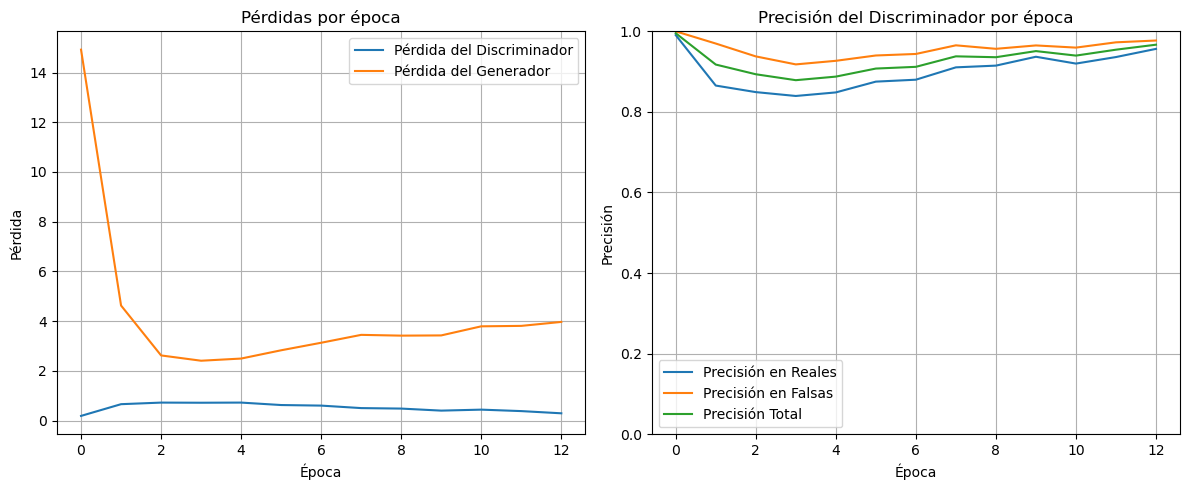

In [17]:
# --- Gráfica de pérdidas ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(metricas[:, 0], label='Pérdida del Discriminador')
plt.plot(metricas[:, 1], label='Pérdida del Generador')
plt.title('Pérdidas por época')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

# --- Gráfica de precisión del discriminador ---
plt.subplot(1, 2, 2)
plt.plot(metricas[:, 2], label='Precisión en Reales')
plt.plot(metricas[:, 3], label='Precisión en Falsas')
plt.plot(metricas[:, 4], label='Precisión Total')
plt.title('Precisión del Discriminador por época')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.ylim(0, 1)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [18]:
def smooth(x,k=15):
  return np.convolve(x,np.ones(k)/k,mode='same')

In [19]:
losses

array([[1.41685581, 2.6909833 ],
       [1.99697316, 3.10534358],
       [1.41759431, 5.17299271],
       ...,
       [0.04023079, 4.54604292],
       [0.02578772, 4.97069168],
       [0.05100854, 4.6561842 ]])

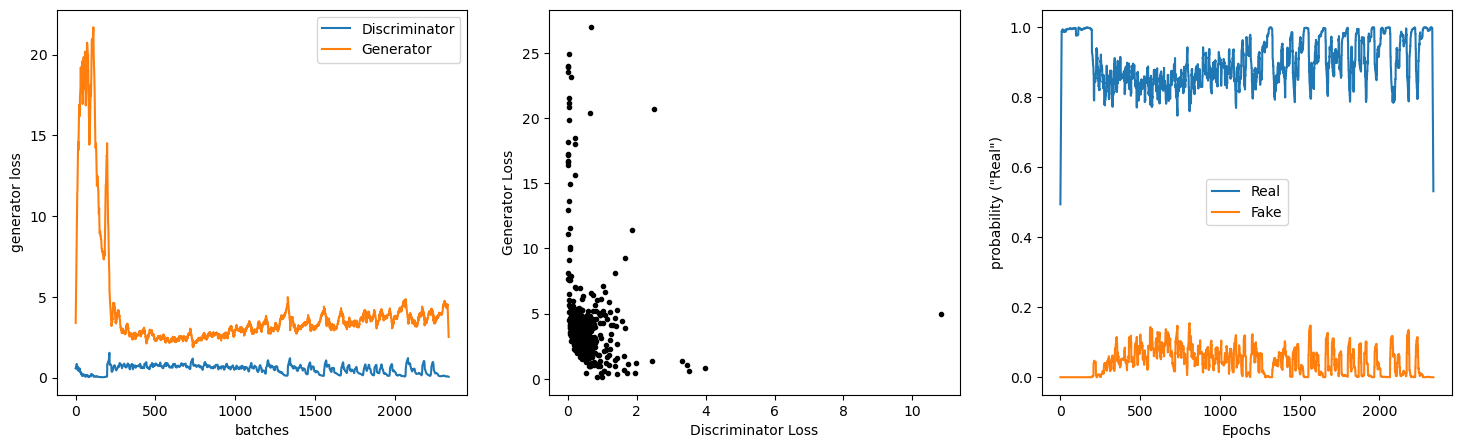

In [21]:
fig, ax = plt.subplots(1,3, figsize=(18,5))

ax[0].plot(smooth(losses[:,0]))
ax[0].plot(smooth(losses[:,1]))
ax[0].set_xlabel('batches')
ax[0].set_ylabel('generator loss')
ax[0].legend(['Discriminator','Generator'])

ax[1].plot(losses[::5,0],losses[::5,1],'k.')
ax[1].set_xlabel('Discriminator Loss')
ax[1].set_ylabel('Generator Loss')

ax[2].plot(smooth(disDecs[:,0]))
ax[2].plot(smooth(disDecs[:,1]))
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel('probability ("Real")')
ax[2].legend(['Real','Fake'])

#### Creando algunas modas generadas

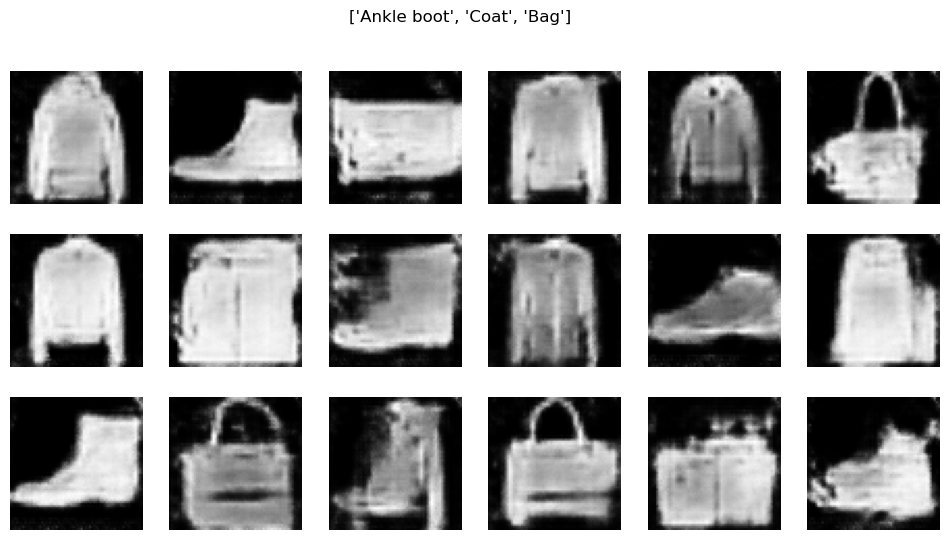

In [22]:

gnet.eval()
fake_data = gnet(torch.randn(batchsize,100,1,1).to(device)).cpu()


fig, axs = plt.subplots(3,6,figsize=(12,6))

for i, ax in enumerate(axs.flatten()):
  ax.imshow(fake_data[i,:,].detach().squeeze(),cmap='gray')
  ax.axis('off')

plt.suptitle(classes_to_focus,y=0.98)
plt.show()